 ### Iterative Self-Reflection RAG

- Iterative Self-Reflection RAG is an advanced Retrieval-Augmented Generation (RAG) technique where the LLM evaluates its own answer before returning it to the user.

- Instead of performing a single retrieval and generation step, the system:

    - Retrieves relevant documents.
   - Generates an answer.
    - Reflects on the quality of the answer.
    - Decides whether the answer is sufficient.
    - If not, reformulates the query and retrieves again.
    - Repeats until a satisfactory answer is produced or a retry limit is reached.

    
 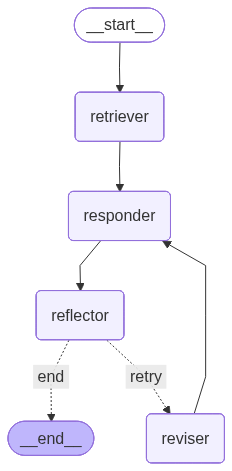

In [ ]:
import os
from  typing import List , Annotated, TypedDict, Sequence, Literal
from pydantic import BaseModel, Field

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from  typing import List , Annotated, TypedDict, Sequence, Literal
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate


from langchain_groq import ChatGroq

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()




In [ ]:
# Initialize global ChatGroq model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="qwen/qwen3-32b")


In [ ]:
### 1. Document Processing

urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/integrations/providers/overview"
]

loaders = [WebBaseLoader(url) for url in urls]

docs=[]

for loader in loaders:
    docs.extend(loader.load())

docs

In [ ]:
## 2. Recursive character txt splitter as vector store

splitter =RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()

vectorstore = FAISS.from_documents(split_docs, embedding)
retriever= vectorstore.as_retriever()

retriever.invoke("what is reward function") # test the retriever

In [ ]:
from typing import Dict, List
from pydantic import BaseModel, Field

class ReflectionRAGState(BaseModel):
    question: str
    retrieved_docs: Dict[str, List[str]] = Field(default_factory=dict)
    answer: str = ""
    reflection: str = ""
    revised: bool = False
    attempts: int = 0

In [ ]:
# nodes
def retrieve_docs(state: ReflectionRAGState) -> ReflectionRAGState:
    docs = retriever.invoke(state.question)

    state.retrieved_docs = {
        f"attempt_{state.attempts}": [
            doc.page_content for doc in docs
        ]
    }

    return state

In [ ]:
def generate_answer(state: ReflectionRAGState) -> ReflectionRAGState:
    context = ""

    for attempt, docs in state.retrieved_docs.items():
        context += f"\n{attempt}:\n"
        for doc in docs:
            context += f"- {doc}\n"

    prompt = f"""
Answer using only the retrieved context.

Question:
{state.question}

Context:
{context}

Answer:
"""

    response = llm.invoke(prompt).content

    state.answer = response   # important

    return state

In [ ]:
def reflect_answer(state: ReflectionRAGState) -> ReflectionRAGState:
    context = ""

    for attempt, docs in state.retrieved_docs.items():
        context += f"\n{attempt}:\n"
        for doc in docs:
            context += f"- {doc[:500]}\n"

    print("========== DEBUG REFLECTOR ==========")
    print("QUESTION:", state.question)
    print("ANSWER EMPTY?", state.answer == "")
    print("DOCS EMPTY?", state.retrieved_docs == {})
    print("ANSWER:", state.answer[:500])
    print("====================================")

    if not state.answer.strip():
        state.reflection = "FAIL"
        return state

    if not state.retrieved_docs:
        state.reflection = "FAIL"
        return state

    prompt = fprompt = f"""
You are evaluating a RAG system.

Question:
{state.question}

Retrieved Context:
{context}

Generated Answer:
{state.answer}

Evaluation Rules:

PASS if:
- The user's question is directly answered.
- The answer contains enough information to satisfy the user.

FAIL if:
- The answer says information is missing.
- The answer says the context does not contain the information.
- The answer says additional resources are required.
- The answer cannot answer the user's question.
- The answer is incomplete.

Return ONLY:

PASS

or

FAIL
"""

    response = llm.invoke(prompt).content.strip().upper()

    print("RAW REFLECTION RESPONSE:", response)

    if "PASS" in response:
        state.reflection = "PASS"
    else:
        state.reflection = "FAIL"

    return state

In [ ]:
def reflection_router(state: ReflectionRAGState):
    if state.reflection == "PASS":
        return "end"

    if state.attempts >= 2:
        return "end"

    return "revise"

In [ ]:
def revise_query(state: ReflectionRAGState) -> ReflectionRAGState:
    state.attempts += 1
    state.revised = True

    context = ""

    for attempt, docs in state.retrieved_docs.items():
        context += f"\n{attempt}:\n"
        for doc in docs:
            context += f"- {doc[:500]}\n"

    prompt = f"""
You are improving a search query for a RAG retriever.

Original question:
{state.question}

Previous retrieved context:
{context}

Previous answer:
{state.answer}

The previous answer failed reflection.

Rewrite the question into a better retrieval query.
Return ONLY the improved search query.
"""

    revised_query = llm.invoke(prompt).content.strip()

    docs = retriever.invoke(revised_query)

    state.retrieved_docs[f"attempt_{state.attempts}"] = [
        doc.page_content for doc in docs
    ]

    return state

In [ ]:
# Build the state graph
builder = StateGraph(ReflectionRAGState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_answer)
builder.add_node("reviser", revise_query)

builder.add_edge(START, "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")

builder.add_conditional_edges(
    "reflector",
    reflection_router,
    {
        "revise": "reviser",
        "end": END
    }
)

builder.add_edge("reviser", "responder")

graph = builder.compile()

In [ ]:
# View the graph
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
test_question = """
How would you build a production-ready AI agent using LangChain, LangGraph,
and external model providers? Explain the role of each component and how they interact.
"""

result = graph.invoke({
    "question": test_question
})

print("\n========== QUESTION ==========")
print(result["question"])

print("\n========== RETRIEVED DOCS ==========")
for attempt, docs in result["retrieved_docs"].items():
    print(f"\n--- {attempt} ---")
    for i, doc in enumerate(docs, start=1):
        print(f"\nDoc {i}:")
        print(doc[:700])

print("\n========== ANSWER ==========")
print(result["answer"])

print("\n========== REFLECTION ==========")
print(result["reflection"])

print("\n========== REVISED ==========")
print(result["revised"])

print("\n========== ATTEMPTS ==========")
print(result["attempts"])

In [ ]:
# Negative scenario

test_question = """
what is Quantum theory
"""

result = graph.invoke({
    "question": test_question
})

print("\n========== QUESTION ==========")
print(result["question"])

print("\n========== RETRIEVED DOCS ==========")
for attempt, docs in result["retrieved_docs"].items():
    print(f"\n--- {attempt} ---")
    for i, doc in enumerate(docs, start=1):
        print(f"\nDoc {i}:")
        print(doc[:700])

print("\n========== ANSWER ==========")
print(result["answer"])

print("\n========== REFLECTION ==========")
print(result["reflection"])

print("\n========== REVISED ==========")
print(result["revised"])

print("\n========== ATTEMPTS ==========")
print(result["attempts"])